In [1]:


# on va explorer l 'exemple de ce lien https://www.kaggle.com/raviolli77/random-forest-in-python#
# donc il faut d'abord faire un fork notebook puis le télécharger et l'uploader dans votre propre espace jupyter

# Breast Cancer Machine Learning ( prédire si le cancer de sein bénin ou malin sur la base d'images)

#+ Contributor: Raul Eulogio, Edits by Brittany Marie Swanson
#+ Originally posted on [inertia7](https://www.inertia7.com/projects/95)
#+ Also contributed to [Data Science Inc.](https://www.datascience.com/resources/notebooks/random-forest-intro)

#Random Forest implémenté pour un dataset contenant des attributs descriptifs d\'images coorespondant à une aspiration faite
# au niveau de la poitrine : en particulier des images pris selon la technique FNA (fine needle aspirate (FNA) of breast mass.)

# - 29 features that were computed for each cell nucleus ( chaque noyau de cellule) with an ID Number and
# - the Diagnosis (Later converted to binary representations: *Malignant* = **1**, *Benign* = **0**).

#  Les étapes d'acquisition des données ont été les suivantes :
# - Les FNA ont été effectuées sur un total de 569 patients,  Une fois cela fait, les échantillons ont ensuite été colorés
#   pour aider à différencier les noyaux cellulaires distingués.
# - Classification manuelle : Samples were classified as cancer-based through biopsy and historical confirmation.
#   Non-cancer samples were confirmed by biopsy or follow ups.
# - Sélection de zones d'études : Users then chose areas of the **FNA** with minimal overlap between nuclei; they then took scans utilizing a digital
#    camera.
# - Identifier le contour des images : Using a software called `Xcyt`, the team created approximate boundaries, which would
#    then used a process called [snakes](https://en.wikipedia.org/wiki/Active_contour_model) which converged to give the exact nuclei boundary.
# - Génération des features : Finally, once the boundaries for the nuclei were set, calculations were made resulting in 29 features, creating this data set!

lien du dataset sur UCI https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29
Pour le télécharger , récupérer le directement de l'onglet data sous kaggle.

In [2]:
# Import modules
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from urllib.request import urlopen

# le style ici c est le package ggplot utilisé en R
plt.style.use('ggplot')
pd.set_option('display.max_columns', 500)

# Load Data
For this section, I'll load the data into a `Pandas` dataframe

In [3]:
breast_cancer = pd.read_csv('data_breast.csv')

In [4]:
breast_cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Les noms des colonnes de notre dataset
names = ['id', 'diagnosis', 'radius_mean',
         'texture_mean', 'perimeter_mean', 'area_mean',
         'smoothness_mean', 'compactness_mean',
         'concavity_mean','concave_points_mean',
         'symmetry_mean', 'fractal_dimension_mean',
         'radius_se', 'texture_se', 'perimeter_se',
         'area_se', 'smoothness_se', 'compactness_se',
         'concavity_se', 'concave_points_se',
         'symmetry_se', 'fractal_dimension_se',
         'radius_worst', 'texture_worst',
         'perimeter_worst', 'area_worst',
         'smoothness_worst', 'compactness_worst',
         'concavity_worst', 'concave_points_worst',
         'symmetry_worst', 'fractal_dimension_worst']

dx = ['Benign', 'Malignant']

## Cleaning
We do some minor cleanage like setting the `id_number` to be the data frame index, along with converting the `diagnosis` to the standard binary 1, 0 representation using the `map()` function.

In [6]:
# Setting 'id_number' as our index
# https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.set_index.html
# l'index du dataframe sera la colonne id et inplace true ( permet de modifié le dataframe en cours)
breast_cancer.set_index('id', inplace= True)

In [7]:
# Converted to binary to help later on with models and plots
# on transforme les M ( pour malin ) en 1 et le B ( pour bénin) en 0
breast_cancer['diagnosis'] = breast_cancer['diagnosis'].map({'M':1, 'B':0})

## Missing Values
Given context of the data set, I know that there is no missing data, but I ran an `apply` method utilizing a lambda expression that checks to see if there was any missing values through each column. Printing the column name and total missing values for that column, iteratively.

In [8]:
breast_cancer.apply(lambda x: x.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

We have to delete this extra column ("unnamed:32" qui a 569 valeurs nulles )since it doesn't contain any data.

This following code  will be used for the random forest model, where the `id_number` won't be relevant.

In [9]:
# For later use in CART models
names_index = names[2:]

Let's preview the data set utilizing the `head()` function which will give the first 5 values of our data frame.

In [11]:
breast_cancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Next, we'll give the dimensions of the data set; where the first value is the number of patients and the second value is the number of features.

We print the data types of our data set this is important because this will often be an indicator of missing data, as well as giving us context to anymore data cleanage.

In [12]:
print("Here's the dimensions of our data frame:\n",
     breast_cancer.shape)
print("Here's the data types of our columns:\n",
     breast_cancer.dtypes)

Here's the dimensions of our data frame:
 (569, 31)
Here's the data types of our columns:
 diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64

## Class Imbalance
The distribution of diagnoses is important because it speaks to class imbalance within machine learning and data mining applications. Class imbalance is a term used to describe when a target class within a data set is outnumbered by another target class (or classes). This can create misleading accuracy metrics, known as an accuracy paradox. To make sure our target classes aren't imbalanced, create a function that will output the distribution of the target classes.

**Note**: If your data set suffers from class imbalance, I suggest reading up on upsampling and downsampling.

On parle d'imbalancing quand  l'événement à prédire appartient à une classe minoritaire ( ou rare ) c 'est à dire représente
moins que 5% des données observées.
A lire : https://www.analyticsvidhya.com/blog/2017/03/imbalanced-classification-problem/

In [44]:
col_vals = breast_cancer["diagnosis"].value_counts()
col_vals


diagnosis
0    357
1    212
Name: count, dtype: int64

Fortunately, this data set does not suffer from severe *class imbalance*.

Next, we will employ a function that gives us standard descriptive statistics for each feature including mean, standard deviation, minimum value, maximum value, and range intervals.

In [15]:
breast_cancer.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


You can see in the maximum row of the chart that our data varies in distribution; this will be important as we consider classification models. Standardization is an important requirement for many classification models that should be handled when implementing pre-processing. Some models (like [neural networks](https://www.datascience.com/resources/webinars/introduction-to-neural-nets-with-the-data-incubator)) can perform poorly if pre-processing isn't considered, so the `describe()` function is a good indicator for standardization. Fortunately, random forest does not require any pre-processing. (For use of categorical data, see [sklearn's Encoding Categorical Data](http://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features) section).

# Creating Training and Test Sets

Let's split the data set into our training and test sets, which will be pseudo-randomly selected to create a 80-20% split. You will use the training set to train the model and perform some optimization. You will use the test set, which will act as unseen data, to assess model performance.

When using this method for machine learning, always be wary of utilizing your test set to create models. Data leakage is a common problem that can result in overfitting. More on data leakage can be found in this [Kaggle article](https://www.kaggle.com/wiki/Leakage)


In [45]:
feature_space = breast_cancer.iloc[:, breast_cancer.columns != 'diagnosis']
feature_class = breast_cancer.iloc[:, breast_cancer.columns == 'diagnosis']


training_set, test_set, class_set, test_class_set = train_test_split(feature_space,
                                                                    feature_class,
                                                                    test_size = 0.20,
                                                                    random_state = 42)

**NOTE**: What I mean when I say that we will "pseudo-randomly" select data is that we will use a random seed generator and set it equal to a number of our choosing. This will ensure the results are the same for anyone who uses this generator, and therefore, that they will be able to replicate this project.

In [46]:
# Cleaning test sets to avoid future warning messages
class_set = class_set.values.ravel()
test_class_set = test_class_set.values.ravel()

# Fitting Random Forest

Now, let's create the model, starting with parameter tuning. Here are the parameters we will be tuning in this tutorial:

+ **max_depth**: The maximum splits for all trees in the forest.
bootstrap: An indicator of whether or not we want to use bootstrap samples when building trees.
+ **max_features**: The maximum number of features that will be used in node splitting — the main difference I previously mentioned between bagging trees and random forest. Typically, you want a value that is less than p, where p is all features in your data set.
+ **criterion**: This is the metric used to asses the stopping criteria for the decision trees.

Once we've instantiated our model, we will go ahead and tune our parameters.

In [47]:
# Set the random state for reproducibility
# lien pour voir les paramèters
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
fit_rf = RandomForestClassifier(random_state=42)

# Hyperparameters Optimization

Utilizing the `GridSearchCV` functionality, let's create a dictionary with parameters we are looking to optimize to create the best model for our data. Setting the `n_jobs` to 3 tells the grid search to run three jobs in parallel, reducing the time the function will take to compute the best parameters. I included the timer to see how long different jobs took; that led me to ultimately decide to use three parallel jobs.

This will help set the parameters we will use to tune one final parameter: the number of trees in our forest.
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [48]:
np.random.seed(42)
start = time.time()

param_dist = {'max_depth': [2, 3, 4],
              'bootstrap': [True, False],
              'max_features': ['auto', 'sqrt', 'log2', None],
              'criterion': ['gini', 'entropy']}
# CV : 10 cross validation
# 3 job en //
# les parametre du dictioannire qu'il va étudier
# fit_rf c 'est l'instation de la méthode RandomForestRegression plus haut qu'on lui passe en entrée pour qu'il sache sur quel
# algo il prépare ces params
cv_rf = GridSearchCV(fit_rf, cv = 10,
                     param_grid=param_dist,
                     n_jobs = 3)

cv_rf.fit(training_set, class_set)
print('Best Parameters using grid search: \n',
      cv_rf.best_params_)
end = time.time()
print('Time taken in grid search: {0: .2f}'.format(end - start))

Best Parameters using grid search: 
 {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 4, 'max_features': 'log2'}
Time taken in grid search:  54.05


c:\Users\ychasser\Documents\python-venvs\ml-dl\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
63 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ychasser\Documents\python-venvs\ml-dl\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ychasser\Documents\python-venvs\ml-dl\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\ychasser\Documents\python-venvs\ml-dl\Lib\site-packages\sklearn\base.py", line 436, in _validate_para

Once we are given the best parameter combination, we set the parameters to our model.

Notice how we didn't utilize the `bootstrap: True` parameter, this will make sense in the following section.

In [49]:
# Set best parameters given by grid search
fit_rf.set_params(criterion = 'gini',
                  max_features = 'log2',
                  max_depth = 3)

RandomForestClassifier(max_depth=3, max_features='log2', random_state=42)

# Out of Bag Error Rate

Another useful feature of random forest is the concept of an out-of-bag (OOB) error rate. Because only two-thirds of the data are used to train each tree when building the forest, one-third of unseen data can be used in a way that is advantageous to our accuracy metrics without being as computationally expensive as something like cross validation, for instance.

As outlined below, when calculating OOB, two parameters have to be changed. Also, by utilizing a `for-loop` across a multitude of forest sizes, we can calculate the OOB error rate and use it to asses how many trees are appropriate for our model!

**NOTE**: When calculating the oob score, setting `bootstrap=True` will produce errors, but is necessary for oob_score calculation as stated on this [example](http://scikit-learn.org/stable/auto_examples/ensemble/plot_ensemble_oob.html)

For the original analysis I compared *Kth Nearest Neighbor*, *Random Forest*, and *Neural Networks*, so most of the analysis was done to compare across different models.

In [74]:
fit_rf.set_params(warm_start=False,
                  oob_score=True)

min_estimators = 10
max_estimators = 100

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf.set_params(n_estimators=i)
    fit_rf.fit(training_set, class_set)

    oob_error = 1 - fit_rf.oob_score_
    error_rate[i] = oob_error


c:\Users\ychasser\Documents\python-venvs\ml-dl\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [75]:
# Convert dictionary to a pandas series for easy plotting
oob_series = pd.Series(error_rate)

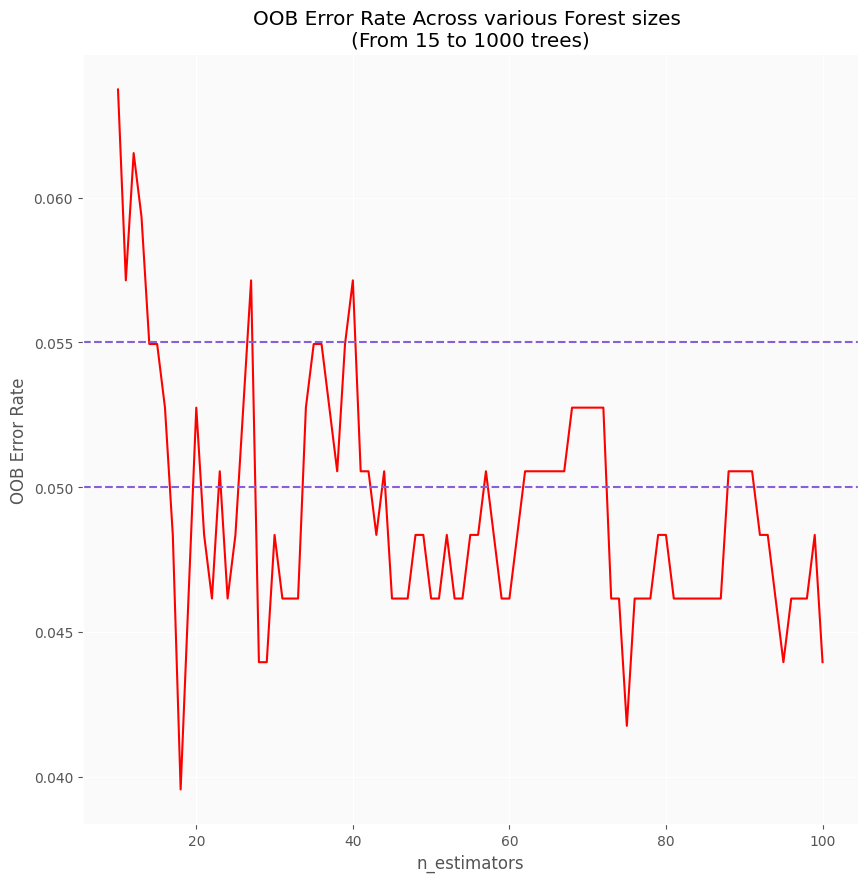

In [76]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.set_facecolor('#fafafa')

oob_series.plot(kind='line',
                color = 'red')
plt.axhline(0.055,
            color='#875FDB',
           linestyle='--')
plt.axhline(0.05,
            color='#875FDB',
           linestyle='--')
plt.xlabel('n_estimators')
plt.ylabel('OOB Error Rate')
plt.title('OOB Error Rate Across various Forest sizes \n(From 15 to 1000 trees)')
plt.show()

The OOB error rate starts to oscilate at around 400 trees, so I will go ahead and use my judgement to use 400 trees in my forest. Using the `pandas` series object I can easily find the OOB error rate for the estimator as follows:

In [77]:
print('OOB Error rate for 100 trees is: {0:.5f}'.format(oob_series[100]))

OOB Error rate for 100 trees is: 0.04396


Utilizing the OOB error rate that was created with the model gives us an unbiased error rate. Since OOB can be calculated with the model estimation, it's helpful when cross validating and/or optimizing hyperparameters prove to be too computationally expensive.

For the sake of this tutorial, I will go over other traditional methods for optimizing machine learning models, including the training and test error route and cross validation metrics.

# Traditional Training and Test Set Split

In order for this methodology to work we will set the number of trees calculated using the OOB error rate, and removing the `warm_start` and `oob_score` parameters. Along with including the `bootstrap` parameter.

In [78]:
fit_rf.set_params(n_estimators=400,
                  bootstrap = True,
                  warm_start=False,
                  oob_score=False)

RandomForestClassifier(max_depth=3, max_features='log2', n_estimators=400,
                       random_state=42)

# Training Algorithm

Next we train the algorithm utilizing the training and target class set we had made earlier.

In [79]:
fit_rf.fit(training_set, class_set)

RandomForestClassifier(max_depth=3, max_features='log2', n_estimators=400,
                       random_state=42)

# Variable Importance

Once we have trained the model, we can assess variable importance. One downside to using ensemble methods with decision trees is that you lose the interpretability a single tree gives. A single tree can outline for us important node splits, as well as variables that were important at each split.


Fortunately, ensemble methods that rely on CART models use a metric to evaluate the homogeneity of splits. Thus, when creating ensembles, these metrics can be utilized to give insight into the important variables used in the training of the model. Two such metrics are **gini impurity** and **entropy**. Many people favor **gini impurity** because it has a lower computational cost than **entropy**, which requires calculating the logarithmic function. For more information, I recommend reading this [article](https://github.com/rasbt/python-machine-learning-book/blob/master/faq/decision-tree-binary.md).

The two metrics vary and from reading documentation online, many people favor `gini impurity` due to the computational cost of `entropy` since it requires calculating the logarithmic function. For more discussion I recommend reading this [article](https://github.com/rasbt/python-machine-learning-book/blob/master/faq/decision-tree-binary.md).

Here we define each metric:

$$Gini\ Impurity = 1 - \sum_i p_i$$

and

$$Entropy = \sum_i -p_i * \log_2 p_i$$

where $p_i$ is defined as the proportion of subsamples that belong to a certain target class.

Since we are utilizing the gini impurity, the impurity measure reaches 0 when all target class labels are the same.

Let's access the feature importance of the model and use a helper function to output the importance of our variables in descending order.

In [80]:
def variable_importance(fit):
    """
    Purpose
    ----------
    Checks if model is fitted CART model then produces variable importance
    and respective indices in dictionary.

    Parameters
    ----------
    * fit:  Fitted model containing the attribute feature_importances_

    Returns
    ----------
    Dictionary containing arrays with importance score and index of columns
    ordered in descending order of importance.
    """
    try:
        if not hasattr(fit, 'fit'):
            return print("'{0}' is not an instantiated model from scikit-learn".format(fit))

        # Captures whether the model has been trained
        if not vars(fit)["estimators_"]:
            return print("Model does not appear to be trained.")
    except KeyError:
        print("Model entered does not contain 'estimators_' attribute.")

    importances = fit.feature_importances_
    indices = np.argsort(importances)[::-1]
    return {'importance': importances,
            'index': indices}

In [81]:
var_imp_rf = variable_importance(fit_rf)

importances_rf = var_imp_rf['importance']

indices_rf = var_imp_rf['index']

In [82]:
def print_var_importance(importance, indices, name_index):
    """
    Purpose
    ----------
    Prints dependent variable names ordered from largest to smallest
    based on information gain for CART model.
    Parameters
    ----------
    * importance: Array returned from feature_importances_ for CART
                models organized by dataframe index
    * indices: Organized index of dataframe from largest to smallest
                based on feature_importances_
    * name_index: Name of columns included in model

    Returns
    ----------
    Prints feature importance in descending order
    """
    print("Feature ranking:")

    for f in range(0, indices.shape[0]):
        i = f
        print("{0}. The feature '{1}' has a Mean Decrease in Impurity of {2:.5f}"
              .format(f + 1,
                      names_index[indices[i]],
                      importance[indices[f]]))

In [83]:
print_var_importance(importances_rf, indices_rf, names_index)


Feature ranking:
1. The feature 'area_worst' has a Mean Decrease in Impurity of 0.12986
2. The feature 'perimeter_worst' has a Mean Decrease in Impurity of 0.12095
3. The feature 'concave_points_worst' has a Mean Decrease in Impurity of 0.11555
4. The feature 'concave_points_mean' has a Mean Decrease in Impurity of 0.10014
5. The feature 'radius_worst' has a Mean Decrease in Impurity of 0.07805
6. The feature 'concavity_mean' has a Mean Decrease in Impurity of 0.06214
7. The feature 'area_mean' has a Mean Decrease in Impurity of 0.05656
8. The feature 'radius_mean' has a Mean Decrease in Impurity of 0.05457
9. The feature 'perimeter_mean' has a Mean Decrease in Impurity of 0.05174
10. The feature 'area_se' has a Mean Decrease in Impurity of 0.04326
11. The feature 'concavity_worst' has a Mean Decrease in Impurity of 0.03866
12. The feature 'compactness_worst' has a Mean Decrease in Impurity of 0.02033
13. The feature 'compactness_mean' has a Mean Decrease in Impurity of 0.01616
14. The

We can see here that our top 5 variables were `area_worst`, `perimeter_worst`, `concave_points_worst`, `concave_points_mean`, `radius_worst`.

This gives us great insight for further analyses like feature engineering, although I won't get into that topic during this tutorial. It can also give us insight into the mind of the practitioner by showing what variables played an important part in the predictions generated by the model. In the case of our test data set, knowing this information would help practitioners in the medical field focus on the top variables and their relationship with breast cancer.

In [86]:
def variable_importance_plot(importance, indices, name_index):
    """
    Purpose
    ----------
    Prints bar chart detailing variable importance for CART model
    NOTE: feature_space list was created because the bar chart
    was transposed and index would be in incorrect order.

    Parameters
    ----------
    * importance: Array returned from feature_importances_ for CART
                models organized by dataframe index
    * indices: Organized index of dataframe from largest to smallest
                based on feature_importances_
    * name_index: Name of columns included in model

    Returns:
    ----------
    Returns variable importance plot in descending order
    """
    index = np.arange(len(names_index))

    importance_desc = sorted(importance)
    feature_space = []
    for i in range(indices.shape[0] - 1, -1, -1):
        feature_space.append(names_index[indices[i]])

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.set_facecolor("lightgray")
    plt.title('Feature importances for Random Forest Model\
    \nBreast Cancer (Diagnostic)')
    plt.barh(index,
             importance_desc,
             align="center",
             color = '#875FDB')
    plt.yticks(index,
               feature_space)

    plt.ylim(-1, 30)
    plt.xlim(0, max(importance_desc) + 0.01)
    plt.xlabel('Mean Decrease in Impurity')
    plt.ylabel('Feature')

    plt.show()
    plt.close()

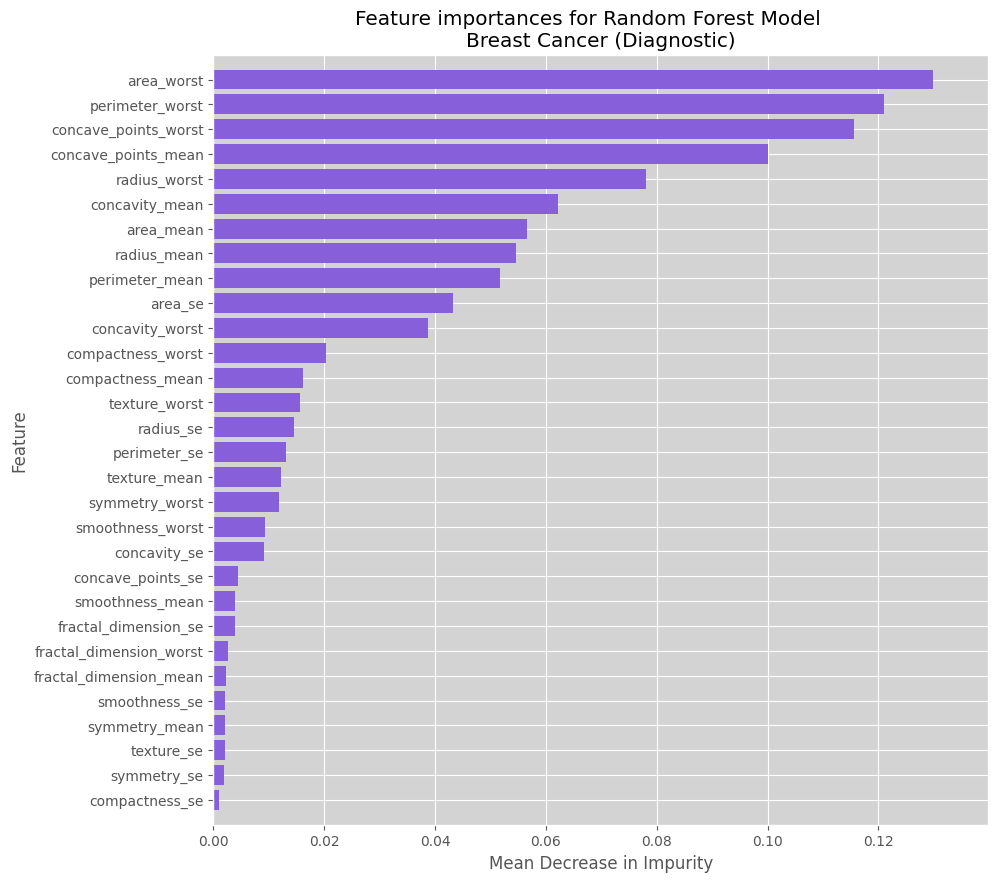

In [87]:
variable_importance_plot(importances_rf, indices_rf, names_index)

The visual above helps drive home the point, since you can clearly see the difference in the importance of variables for the ensemble method. Certain cutoff points can be made to reduce the inclusion of features and can help in the accuracy of the model, since we'll be removing what is considered noise within our feature space.


# Cross Validation

Cross validation is a powerful tool that is used for estimating the predictive power of your model, and it performs better than the conventional training and test set. Using cross validation, we can create multiple training and test sets and average the scores to give us a less biased metric.

In this case, we will create 10 sets within our data set that calculate the estimations we have done already, then average the prediction error to give us a more accurate representation of our model's prediction power. The model's performance can vary significantly when utilizing different training and test sets.

**Suggested Reading**: For a more concise explanation of *Cross Validation* I recommend reading [An Introduction to Statistical Learnings with Applications in R](http://www-bcf.usc.edu/~gareth/ISL/), specifically chapter 5.1!

## K-Fold Cross Validation

Here we are employing K-fold cross validation; more specifically, 10 folds. We are creating 10 subsets of our data on which to employ the training and test set methodology; then we will average the accuracy for all folds to give us our estimation.

Within a random forest context, if your data set is significantly large, you can choose to not do cross validation and instead use the OOB error rate as an unbiased metric for computational costs. But for the purposes of this tutorial, I included it to show the different accuracy metrics available.

In [88]:
def cross_val_metrics(fit, training_set, class_set, estimator, print_results = True):
    """
    Purpose
    ----------
    Function helps automate cross validation processes while including
    option to print metrics or store in variable

    Parameters
    ----------
    fit: Fitted model
    training_set:  Data_frame containing 80% of original dataframe
    class_set:     data_frame containing the respective target vaues
                      for the training_set
    print_results: Boolean, if true prints the metrics, else saves metrics as
                      variables

    Returns
    ----------
    scores.mean(): Float representing cross validation score
    scores.std() / 2: Float representing the standard error (derived
                from cross validation score's standard deviation)
    """
    my_estimators = {
    'rf': 'estimators_',
    'nn': 'out_activation_',
    'knn': '_fit_method'
    }
    try:
        # Captures whether first parameter is a model
        if not hasattr(fit, 'fit'):
            return print("'{0}' is not an instantiated model from scikit-learn".format(fit))

        # Captures whether the model has been trained
        if not vars(fit)[my_estimators[estimator]]:
            return print("Model does not appear to be trained.")

    except KeyError as e:
        print("'{0}' does not correspond with the appropriate key inside the estimators dictionary. \
\nPlease refer to function to check `my_estimators` dictionary.".format(estimator))
        raise

    n = KFold(n_splits=10)
    scores = cross_val_score(fit,
                         training_set,
                         class_set,
                         cv = n)
    if print_results:
        for i in range(0, len(scores)):
            print("Cross validation run {0}: {1: 0.3f}".format(i, scores[i]))
        print("Accuracy: {0: 0.3f} (+/- {1: 0.3f})"\
              .format(scores.mean(), scores.std() / 2))
    else:
        return scores.mean(), scores.std() / 2

In [89]:
cross_val_metrics(fit_rf,
                  training_set,
                  class_set,
                  'rf',
                  print_results = True)

Cross validation run 0:  1.000
Cross validation run 1:  0.957
Cross validation run 2:  0.935
Cross validation run 3:  0.935
Cross validation run 4:  0.957
Cross validation run 5:  0.978
Cross validation run 6:  0.933
Cross validation run 7:  0.889
Cross validation run 8:  1.000
Cross validation run 9:  0.889
Accuracy:  0.947 (+/-  0.019)


# Test Set Metrics

Using the test set that was created earlier, let's examine another metric for the evaluation of our model. You'll recall that that we didn't touch the test set until now — after we had completed hyperparamter optimization — to avoid the problem of data leakage.

Here, I have created a confusion matrix showcasing the following metrics:

| n = Sample Size | Predicted Benign | Predicted Malignant |
|-----------------|------------------|---------------------|
| Actual Benign | *True Negative* | *False Positive* |
| Actual Malignant | *False Negative* | *True Positive* |

In [90]:
predictions_rf = fit_rf.predict(test_set)

## Confusion Matrix
Here we create a confusion matrix visual with `seaborn` and transposing the matrix when creating the heatmap.

In [91]:
def create_conf_mat(test_class_set, predictions):
    """Function returns confusion matrix comparing two arrays"""
    if (len(test_class_set.shape) != len(predictions.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (test_class_set.shape != predictions.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = test_class_set,
                                        columns = predictions)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

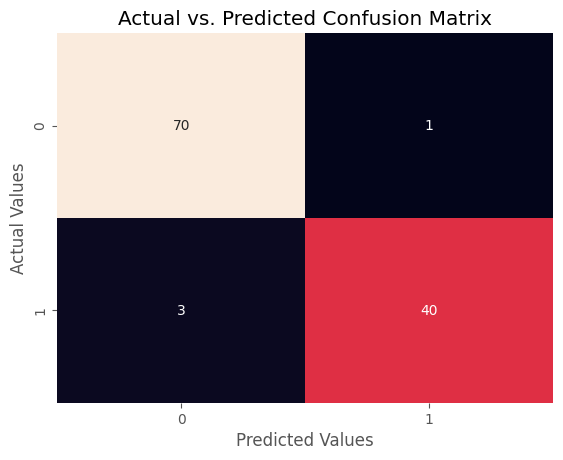

In [92]:
conf_mat = create_conf_mat(test_class_set, predictions_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [93]:
accuracy_rf = fit_rf.score(test_set, test_class_set)

print("Here is our mean accuracy on the test set:\n {0:.3f}"\
      .format(accuracy_rf))

Here is our mean accuracy on the test set:
 0.965


In [94]:
# Here we calculate the test error rate!
test_error_rate_rf = 1 - accuracy_rf
print("The test error rate for our model is:\n {0: .4f}"\
      .format(test_error_rate_rf))

The test error rate for our model is:
  0.0351


As you can see we got a very similar error rate for our test set that we did for our OOB, which is a good sign for our model.

# ROC Curve Metrics

A receiver operating characteristic (ROC) curve calculates the false positive rates and true positive rates across different thresholds. Let's graph these calculations.

If our curve is located in the top left corner of the plot, that indicates an ideal model; i.e., a false positive rate of 0 and true positive rate of 1. On the other hand, a ROC curve that is at 45 degrees is indicative of a model that is essentially randomly guessing.

We will also calculate the area under the curve (AUC). The AUC is used as a metric to differentiate the prediction power of the model for patients with cancer and those without it. Typically, a value closer to 1 means that our model was able to differentiate correctly from a random sample of the two target classes of two patients with and without the disease.

In [98]:
# We grab the second array from the output which corresponds to
# to the predicted probabilites of positive classes
# Ordered wrt fit.classes_ in our case [0, 1] where 1 is our positive class
predictions_prob = fit_rf.predict_proba(test_set)[:, 1]
print(predictions_prob)


fpr2, tpr2, rate = roc_curve(test_class_set,
                          predictions_prob,
                          pos_label = 1)
rate


[0.04516519 0.98003647 0.97490865 0.03196592 0.02265033 0.99046974
 0.98707116 0.89421706 0.6126704  0.02794363 0.0456498  0.95303412
 0.09923562 0.82902432 0.028737   0.97133517 0.07317002 0.02034829
 0.02154891 0.98744145 0.19926331 0.01985512 0.99050563 0.0288402
 0.03891686 0.10277861 0.03173052 0.05095604 0.01930547 0.9905047
 0.03579872 0.0185911  0.10104145 0.06844621 0.01867469 0.01877453
 0.62380229 0.05613259 0.98673294 0.11283935 0.01997458 0.96617688
 0.02721626 0.01909739 0.18167819 0.04819972 0.06943498 0.05732393
 0.0470492  0.0741842  0.96501975 0.99043029 0.22069926 0.18637284
 0.0301343  0.02745187 0.02847628 0.98947442 0.5914282  0.01866494
 0.01909862 0.98886936 0.98863569 0.0669722  0.02472651 0.09351416
 0.98912899 0.97661854 0.02005278 0.07023968 0.74413547 0.97384626
 0.02198922 0.97738305 0.04190763 0.06667984 0.04474    0.29220512
 0.01837179 0.0880501  0.90633439 0.0184411  0.2996807  0.98533812
 0.74980329 0.96355289 0.7561102  0.98481558 0.05908634 0.029647

array([       inf, 0.99050563, 0.62380229, 0.6126704 , 0.5914282 ,
       0.29997141, 0.29220512, 0.22069926, 0.19926331, 0.0185911 ,
       0.0184411 , 0.01837179])

In [97]:
auc_rf = auc(fpr2, tpr2)
auc_rf

0.996069439895185

In [ ]:
def plot_roc_curve(fpr, tpr, auc, estimator, xlim=None, ylim=None):
    """
    Purpose
    ----------
    Function creates ROC Curve for respective model given selected parameters.
    Optional x and y limits to zoom into graph

    Parameters
    ----------
    * fpr: Array returned from sklearn.metrics.roc_curve for increasing
            false positive rates
    * tpr: Array returned from sklearn.metrics.roc_curve for increasing
            true positive rates
    * auc: Float returned from sklearn.metrics.auc (Area under Curve)
    * estimator: String represenation of appropriate model, can only contain the
    following: ['knn', 'rf', 'nn']
    * xlim: Set upper and lower x-limits
    * ylim: Set upper and lower y-limits
    """
    my_estimators = {'knn': ['Kth Nearest Neighbor', 'deeppink'],
              'rf': ['Random Forest', 'red'],
              'nn': ['Neural Network', 'purple']}

    try:
        plot_title = my_estimators[estimator][0]
        color_value = my_estimators[estimator][1]
    except KeyError as e:
        print("'{0}' does not correspond with the appropriate key inside the estimators dictionary. \
\nPlease refer to function to check `my_estimators` dictionary.".format(estimator))
        raise

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_facecolor('#fafafa')

    plt.plot(fpr, tpr,
             color=color_value,
             linewidth=1)
    plt.title('ROC Curve For {0} (AUC = {1: 0.3f})'\
              .format(plot_title, auc))

    plt.plot([0, 1], [0, 1], 'k--', lw=2) # Add Diagonal line
    plt.plot([0, 0], [1, 0], 'k--', lw=2, color = 'black')
    plt.plot([1, 0], [1, 1], 'k--', lw=2, color = 'black')
    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()
    plt.close()

C:\Temp\ipykernel_28760\2153116955.py:42: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 0], [1, 0], 'k--', lw=2, color = 'black')
C:\Temp\ipykernel_28760\2153116955.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([1, 0], [1, 1], 'k--', lw=2, color = 'black')


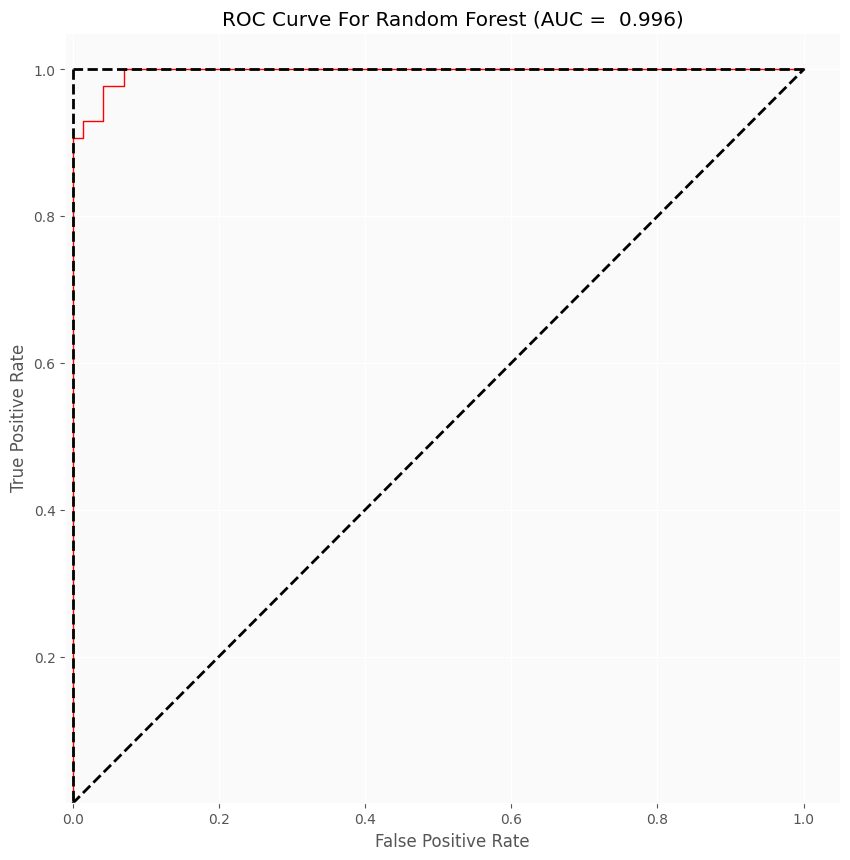

In [ ]:
plot_roc_curve(fpr2, tpr2, auc_rf, 'rf',
               xlim=(-0.01, 1.05),
               ylim=(0.001, 1.05))

Our model did exceptional with an AUC over .90, now we do a zoomed in view to showcase the closeness our ROC Curve is relative to the ideal ROC Curve.

C:\Temp\ipykernel_28760\2153116955.py:42: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 0], [1, 0], 'k--', lw=2, color = 'black')
C:\Temp\ipykernel_28760\2153116955.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([1, 0], [1, 1], 'k--', lw=2, color = 'black')


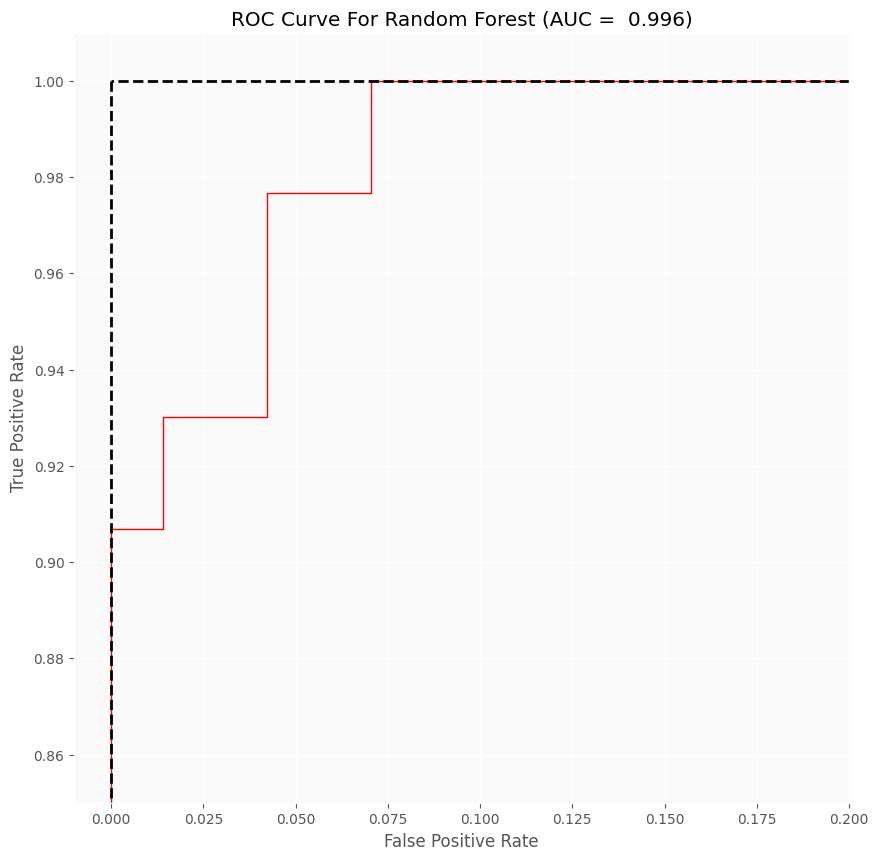

In [ ]:
plot_roc_curve(fpr2, tpr2, auc_rf, 'rf',
               xlim=(-0.01, 0.2),
               ylim=(0.85, 1.01))

# Classification Report

The classification report is available through `sklearn.metrics`, this report gives many important classification metrics including:
+ `Precision`: also the positive predictive value, is the number of correct predictions divided by the number of correct predictions plus false positives, so $tp / (tp + fp)$
+ `Recall`: also known as the sensitivity, is the number of correct predictions divided by the total number of instances so $tp / (tp + fn)$ where $fn$ is the number of false negatives
+ `f1-score`: this is defined as the *weighted harmonic mean* of both the precision and recall, where the f1-score at 1 is the best value and worst value at 0, as defined by the [documentation](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support)
+ `support`: number of instances that are the correct target values

Across the board, we can see that our model provided great insight into classifying patients based on FNA scans. Other important metrics to consider would be the false positive rate, since within this context it would be bad for the model to tell someone that they are cancer free when in reality they have cancer.


In [100]:
def print_class_report(predictions, alg_name):
    """
    Purpose
    ----------
    Function helps automate the report generated by the
    sklearn package. Useful for multiple model comparison

    Parameters:
    ----------
    predictions: The predictions made by the algorithm used
    alg_name: String containing the name of the algorithm used

    Returns:
    ----------
    Returns classification report generated from sklearn.
    """
    print('Classification Report for {0}:'.format(alg_name))
    print(classification_report(predictions,
            test_class_set,
            target_names = dx))

In [101]:
class_report = print_class_report(predictions_rf, 'Random Forest')

Classification Report for Random Forest:
              precision    recall  f1-score   support

      Benign       0.99      0.96      0.97        73
   Malignant       0.93      0.98      0.95        41

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



## Metrics for Random Forest

Here I've accumulated the various metrics we used through this tutorial in a simple table! Showcasing the power and effectiveness of Random Forest Modeling.

| Model | OOB Error Rate | Test Error Rate | Cross Validation Score | AUC |
|-------|----------------|------------------------|-----------------|-----|
| Random Forest | 0.04835 |  0.0351 | 0.947 (+/-  0.019) | 0.967 |

# Conclusions

We've now gone through a number of metrics to assess the capabilities of our random forest, but there's still much that can be done using background information from the data set. Feature engineering would be a powerful tool for extracting information and moving forward into the research phase, and would help define key metrics to utilize when optimizing model parameters.

There have been advancements with image classification in the past decade that make it possible to use images instead of extracted features from those images, but this data set is a great resource for making use of machine learning processes and concepts. If you have any suggestions, recommendations, or corrections please reach out to me.

